In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!pip install ipywidgets --quiet
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import ipywidgets as widgets
from IPython.display import display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.3 MB/s eta 0:00:00


In [7]:
path = '/content/drive/MyDrive/Internship_cancer /Cancer_Data.csv'
df = pd.read_csv(path)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [9]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [10]:
important_features = ['radius_mean', 'perimeter_mean', 'concavity_mean', 'area_worst', 'concave points_mean']
X = df[important_features]
y = df['diagnosis']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [14]:
y_pred = model.predict(X_test_scaled)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, output_dict=True)
accuracy = accuracy_score(y_test, y_pred)

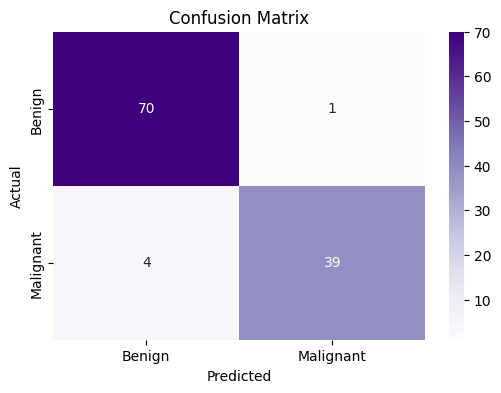

In [15]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

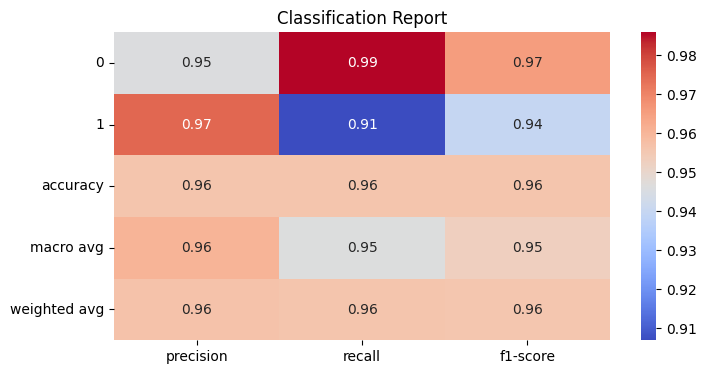

In [16]:
class_df = pd.DataFrame(class_report).iloc[:-1, :].T  # Exclude 'accuracy'
plt.figure(figsize=(8, 4))
sns.heatmap(class_df, annot=True, cmap='coolwarm')
plt.title('Classification Report')
plt.show()

In [17]:
print(f"✅ Accuracy Score: {round(accuracy * 100, 2)}%")

✅ Accuracy Score: 95.61%


In [18]:
radius_mean = widgets.FloatText(description="Radius Mean:")
perimeter_mean = widgets.FloatText(description="Perimeter Mean:")
concavity_mean = widgets.FloatText(description="Concavity Mean:")
area_worst = widgets.FloatText(description="Area Worst:")
concave_points_mean = widgets.FloatText(description="Concave Pts Mean:")
predict_button = widgets.Button(description="Predict")
prediction_output = widgets.Label(value="")

In [19]:
def predict_breast_cancer(b):
    input_data = pd.DataFrame([[
        radius_mean.value, perimeter_mean.value, concavity_mean.value,
        area_worst.value, concave_points_mean.value
    ]], columns=important_features)

    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    prediction_output.value = "🧪 Prediction: Malignant" if prediction == 1 else "🩺 Prediction: Benign"

predict_button.on_click(predict_breast_cancer)

# 📲 Display UI
display(
    widgets.HTML("<h3>Breast Cancer Prediction Tool (Logistic Regression)</h3>"),
    radius_mean, perimeter_mean, concavity_mean,
    area_worst, concave_points_mean,
    predict_button, prediction_output
)

HTML(value='<h3>Breast Cancer Prediction Tool (Logistic Regression)</h3>')

FloatText(value=0.0, description='Radius Mean:')

FloatText(value=0.0, description='Perimeter Mean:')

FloatText(value=0.0, description='Concavity Mean:')

FloatText(value=0.0, description='Area Worst:')

FloatText(value=0.0, description='Concave Pts Mean:')

Button(description='Predict', style=ButtonStyle())

Label(value='')